# CIR Data Preprocessing Pipeline — Visualization

This notebook demonstrates the CIR preprocessing pipeline on the UWB dataset:
1. Physics normalization (divide by RXPACC)
2. Leading edge detection (search window [740, 810])
3. Asymmetric cropping (60 samples: 10 before + 50 after leading edge)
4. Instance normalization (min-max to [0, 1])

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

In [10]:
# ---------- Load dataset ----------
DATA_PATH = os.path.join("..", "dataset", "channels", "combined_uwb_dataset.csv")
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Source file (row 0): {df['Source_File'].iloc[0]}")

Dataset shape: (3600, 1036)
Source file (row 0): 12.79m_nlos_c1.csv


In [11]:
# ---------- Extract CIR waveform from first row ----------
cir_cols = [f"CIR{i}" for i in range(1016)]
raw_cir = df.iloc[0][cir_cols].values.astype(np.float64)
rxpacc = df.iloc[0]["RXPACC"]

print(f"RXPACC: {rxpacc}")
print(f"Raw CIR range: [{raw_cir.min():.2f}, {raw_cir.max():.2f}]")

RXPACC: 110
Raw CIR range: [4.00, 1155.00]


In [12]:
# ---------- Step 1: Physics Normalization ----------
norm_cir = raw_cir / rxpacc
print(f"Physics-normalized CIR range: [{norm_cir.min():.4f}, {norm_cir.max():.4f}]")

Physics-normalized CIR range: [0.0364, 10.5000]


In [13]:
# ---------- Step 2: Leading Edge Detection ----------
SEARCH_START = 740
SEARCH_END = 810

# Find peak within search window
search_window = norm_cir[SEARCH_START:SEARCH_END]
peak_idx_local = np.argmax(search_window)
peak_idx = SEARCH_START + peak_idx_local

# Noise threshold from pre-window region
noise_region = norm_cir[:SEARCH_START]
noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)
threshold = noise_mean + 3 * noise_std

# Backtrack from peak to find leading edge
leading_edge = peak_idx
for i in range(peak_idx, SEARCH_START - 1, -1):
    if norm_cir[i] < threshold:
        leading_edge = i + 1
        break

print(f"Peak index: {peak_idx}")
print(f"Noise threshold: {threshold:.6f} (mean={noise_mean:.6f}, std={noise_std:.6f})")
print(f"Detected leading edge: {leading_edge}")

Peak index: 751
Noise threshold: 1.437980 (mean=0.513649, std=0.308110)
Detected leading edge: 742


In [14]:
# ---------- Step 3: Asymmetric Cropping ----------
PRE_SAMPLES = 10
POST_SAMPLES = 50
CROP_SIZE = PRE_SAMPLES + POST_SAMPLES  # 60

crop_start = leading_edge - PRE_SAMPLES
crop_end = leading_edge + POST_SAMPLES

# Pad if necessary (shouldn't be needed for typical indices)
if crop_start < 0:
    pad_left = abs(crop_start)
    cropped = np.concatenate([np.zeros(pad_left), norm_cir[:crop_end]])
elif crop_end > len(norm_cir):
    pad_right = crop_end - len(norm_cir)
    cropped = np.concatenate([norm_cir[crop_start:], np.zeros(pad_right)])
else:
    cropped = norm_cir[crop_start:crop_end]

print(f"Crop window: [{crop_start}, {crop_end})")
print(f"Cropped shape: {cropped.shape}")

Crop window: [732, 792)
Cropped shape: (60,)


In [15]:
# ---------- Step 4: Instance Normalization (Min-Max) ----------
c_min, c_max = cropped.min(), cropped.max()
if c_max - c_min > 0:
    cropped_norm = (cropped - c_min) / (c_max - c_min)
else:
    cropped_norm = np.zeros_like(cropped)

print(f"Instance-normalized range: [{cropped_norm.min():.4f}, {cropped_norm.max():.4f}]")

Instance-normalized range: [0.0000, 1.0000]


Figure saved to ..\figures\cir_preprocessing_pipeline.png


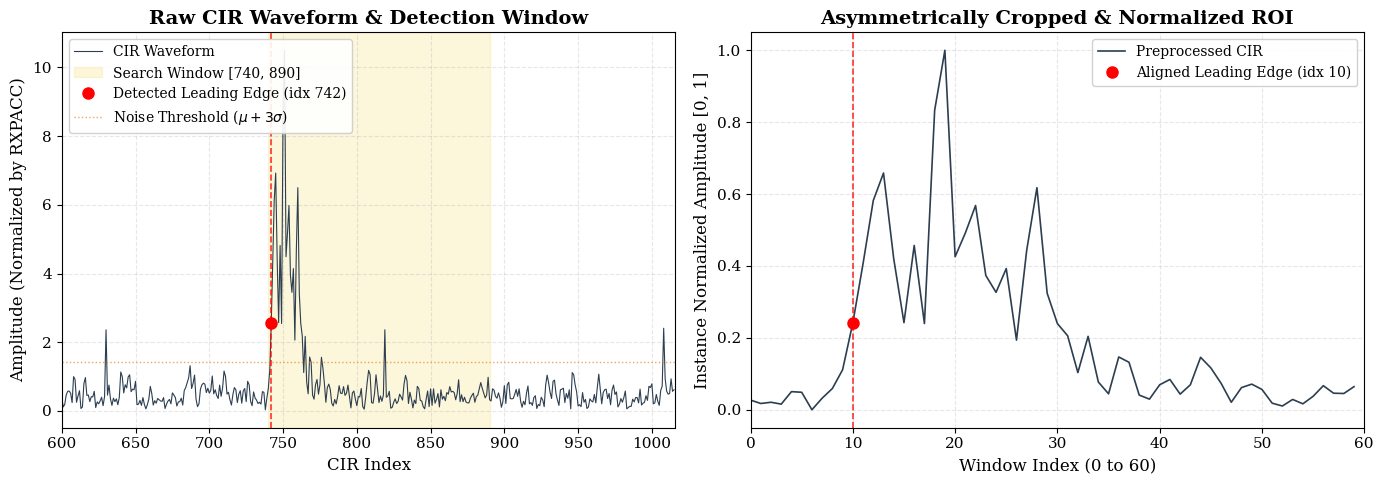

In [16]:
# ---------- Publication-Quality Figure ----------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ===== Left: Raw Signal & Search Window =====
ax1.plot(np.arange(len(norm_cir)), norm_cir, color="#2c3e50", linewidth=0.8, label="CIR Waveform")

# Search window shading
ax1.axvspan(SEARCH_START, SEARCH_END, alpha=0.15, color="#f1c40f", label=f"Search Window [{SEARCH_START}, {SEARCH_END}]")

# Leading edge marker
ax1.axvline(x=leading_edge, color="red", linestyle="--", linewidth=1.2, alpha=0.8)
ax1.plot(leading_edge, norm_cir[leading_edge], "o", color="red", markersize=8, zorder=5, label=f"Detected Leading Edge (idx {leading_edge})")

# Noise threshold line
ax1.axhline(y=threshold, color="#e67e22", linestyle=":", linewidth=1.0, alpha=0.7, label=f"Noise Threshold ($\\mu + 3\\sigma$)")

ax1.set_xlim(600, 1016)
ax1.set_xlabel("CIR Index")
ax1.set_ylabel("Amplitude (Normalized by RXPACC)")
ax1.set_title("Raw CIR Waveform & Detection Window")
ax1.legend(loc="upper left", framealpha=0.9, edgecolor="#cccccc")

# ===== Right: Cropped & Normalized ROI =====
ax2.plot(np.arange(CROP_SIZE), cropped_norm, color="#2c3e50", linewidth=1.2, label="Preprocessed CIR")

# Aligned leading edge at index 10
ax2.axvline(x=PRE_SAMPLES, color="red", linestyle="--", linewidth=1.2, alpha=0.8)
ax2.plot(PRE_SAMPLES, cropped_norm[PRE_SAMPLES], "o", color="red", markersize=8, zorder=5,
         label=f"Aligned Leading Edge (idx {PRE_SAMPLES})")

ax2.set_xlim(0, CROP_SIZE)
ax2.set_ylim(-0.05, 1.05)
ax2.set_xlabel("Window Index (0 to 60)")
ax2.set_ylabel("Instance Normalized Amplitude [0, 1]")
ax2.set_title("Asymmetrically Cropped & Normalized ROI")
ax2.legend(loc="upper right", framealpha=0.9, edgecolor="#cccccc")

plt.tight_layout()

# Save figure
SAVE_PATH = os.path.join("..", "figures")
os.makedirs(SAVE_PATH, exist_ok=True)
fig.savefig(os.path.join(SAVE_PATH, "cir_preprocessing_pipeline.png"), dpi=300, bbox_inches="tight", facecolor="white")
print(f"Figure saved to {os.path.join(SAVE_PATH, 'cir_preprocessing_pipeline.png')}")
plt.show()